In [38]:
# Get and load color map (handles if it is in another folder)
from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd()
while not (cwd / "color_map.py").exists():
    cwd = cwd.parent
sys.path.insert(0, str(cwd))
from color_map import make_color_map

v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Load matplotlib style (handles if in another folder)
from pathlib import Path
cwd = Path.cwd()
while not (cwd / "plos.mplstyle").exists():
    cwd = cwd.parent

style_path = Path(cwd / 'plos.mplstyle')
plt.style.use(style_path)


from config import SimParam, Config  # Classes
from pathlib import Path

all_pqif = [0, 0.25, 0.5, 0.75, 1]
seeds = range(50)

# Oscillations
oscillation_sims = [
    SimParam(1, -8.5, 14.56),
    SimParam(2, -12.3, 10.76),
    SimParam(3, -17.0, 8.21),
    SimParam(4, -22.0, 7.33),
]

oscillations = Config(
    name="oscillations",
    sims=oscillation_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(oscillations))

# Sequences
sequence_sims = [
    SimParam(9, -8.5, 14.56),
    SimParam(10, -12.3, 10.76),
    SimParam(11, -17.0, 8.21),
    SimParam(12, -22.0, 7.33),
]

sequences = Config(
    name="sequences",
    sims=sequence_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(sequences))

configs = [oscillations, sequences]


# Fig
figure_folder = Path("figures_all\july\motifs")
figure_folder.mkdir(parents=True, exist_ok=True)

# Base
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)


Config name: oscillations
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 1 : (vrest=-8.5, gain=14.56), 2 : (vrest=-12.3, gain=10.76), 3 : (vrest=-17.0, gain=8.21), 4 : (vrest=-22.0, gain=7.33)
  across 50 seeds
  Optional parameters:
[]
Config name: sequences
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 9 : (vrest=-8.5, gain=14.56), 10 : (vrest=-12.3, gain=10.76), 11 : (vrest=-17.0, gain=8.21), 12 : (vrest=-22.0, gain=7.33)
  across 50 seeds
  Optional parameters:
[]


In [39]:
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd


weights_dict = {}
rows = []

for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    for sim_param, pqif, seed, _ in cfg.iter_params():
        sim = sim_param.sim
        vrest = sim_param.vrest
        gain = sim_param.gain

        
        simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'  # Shared across dataframe and dictionary

        # ------------------------------ Initial matrix (with zero weights) ------------------------------
        file_path_iloop_0 = base_path / f"simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_0_seed_{seed}"

        M = np.loadtxt(file_path_iloop_0, delimiter=',')

        # ------------------------------ Info about sparsity ------------------------------

        zeros = M == 0  # matrix indicating which weights were initialized to zero
        num_zero_weights = np.sum(zeros)
        num_non_zero_weights = np.sum(~zeros)
        frac_zero_weights = f"{np.sum(zeros) / M.size:.2f}" # should be around 0.7

        # ------------------------------ Matrix after training ------------------------------

        # Load matrix
        file_path_iloop_11 = base_path / f'simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}'

        W_unfiltered = np.loadtxt(file_path_iloop_11, delimiter=',')

        # ------------------------------ Filtered data: Exclude weights initialized to zero ------------------------------
        
        W_filtered = W_unfiltered[~zeros]  # Omit zeros, becomes 1D
        weights_dict[simulation_id] = W_filtered  # Add filtered weights to dictionary; is flattened

        mean = np.mean(W_filtered)  # Mean
        std_pop = np.std(W_filtered)  # Standard deviation (population)
        std_sample = np.std(W_filtered, ddof=1)  # Standard deviation (sample)

        if pqif == 1:
            gain = 10.74


        # ------------------------------ Final stats ------------------------------


        row = [simulation_id, cfg.name, sim, vrest, gain, 
                pqif, seed, mean, std_pop, std_sample, 
                num_zero_weights, num_non_zero_weights, frac_zero_weights]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
        rows.append(row)  # Append row to what becomes the dataframe later

# ------------------------------ Make dataframe ------------------------------

columns = ['config', 'dynamic', 'simulation', 'vrest', 'gain', 
           'pqif', 'seed',  'mean', 'std_pop', 'std_sample', 
           'num_zero_weights', 'num_non_zero_weights', 'frac_zero_weights']
df = pd.DataFrame(rows, columns=columns)
df.to_csv("statistics_connectivity.csv", index=False)

# Part to copy for reusing csv
loaded_df = pd.read_csv("statistics_connectivity.csv") 
wDF = loaded_df.copy()
wDF.head(5)

0: oscillations
1: sequences


,config,dynamic,simulation,vrest,gain,pqif,seed,mean,std_pop,std_sample,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_sim_1_pqif_0_seed_0,oscillations,1,-8.5,14.56,0.0,0,0.000267,0.426141,0.426159,28062,11938,0.7
1,oscillations_sim_1_pqif_0_seed_1,oscillations,1,-8.5,14.56,0.0,1,-0.000349,0.426364,0.426382,28063,11937,0.7
2,oscillations_sim_1_pqif_0_seed_2,oscillations,1,-8.5,14.56,0.0,2,0.000812,0.399953,0.399970,28070,11930,0.7
3,oscillations_sim_1_pqif_0_seed_3,oscillations,1,-8.5,14.56,0.0,3,0.000729,0.420193,0.420211,28062,11938,0.7
4,oscillations_sim_1_pqif_0_seed_4,oscillations,1,-8.5,14.56,0.0,4,0.000024,0.441818,0.441836,28068,11932,0.7


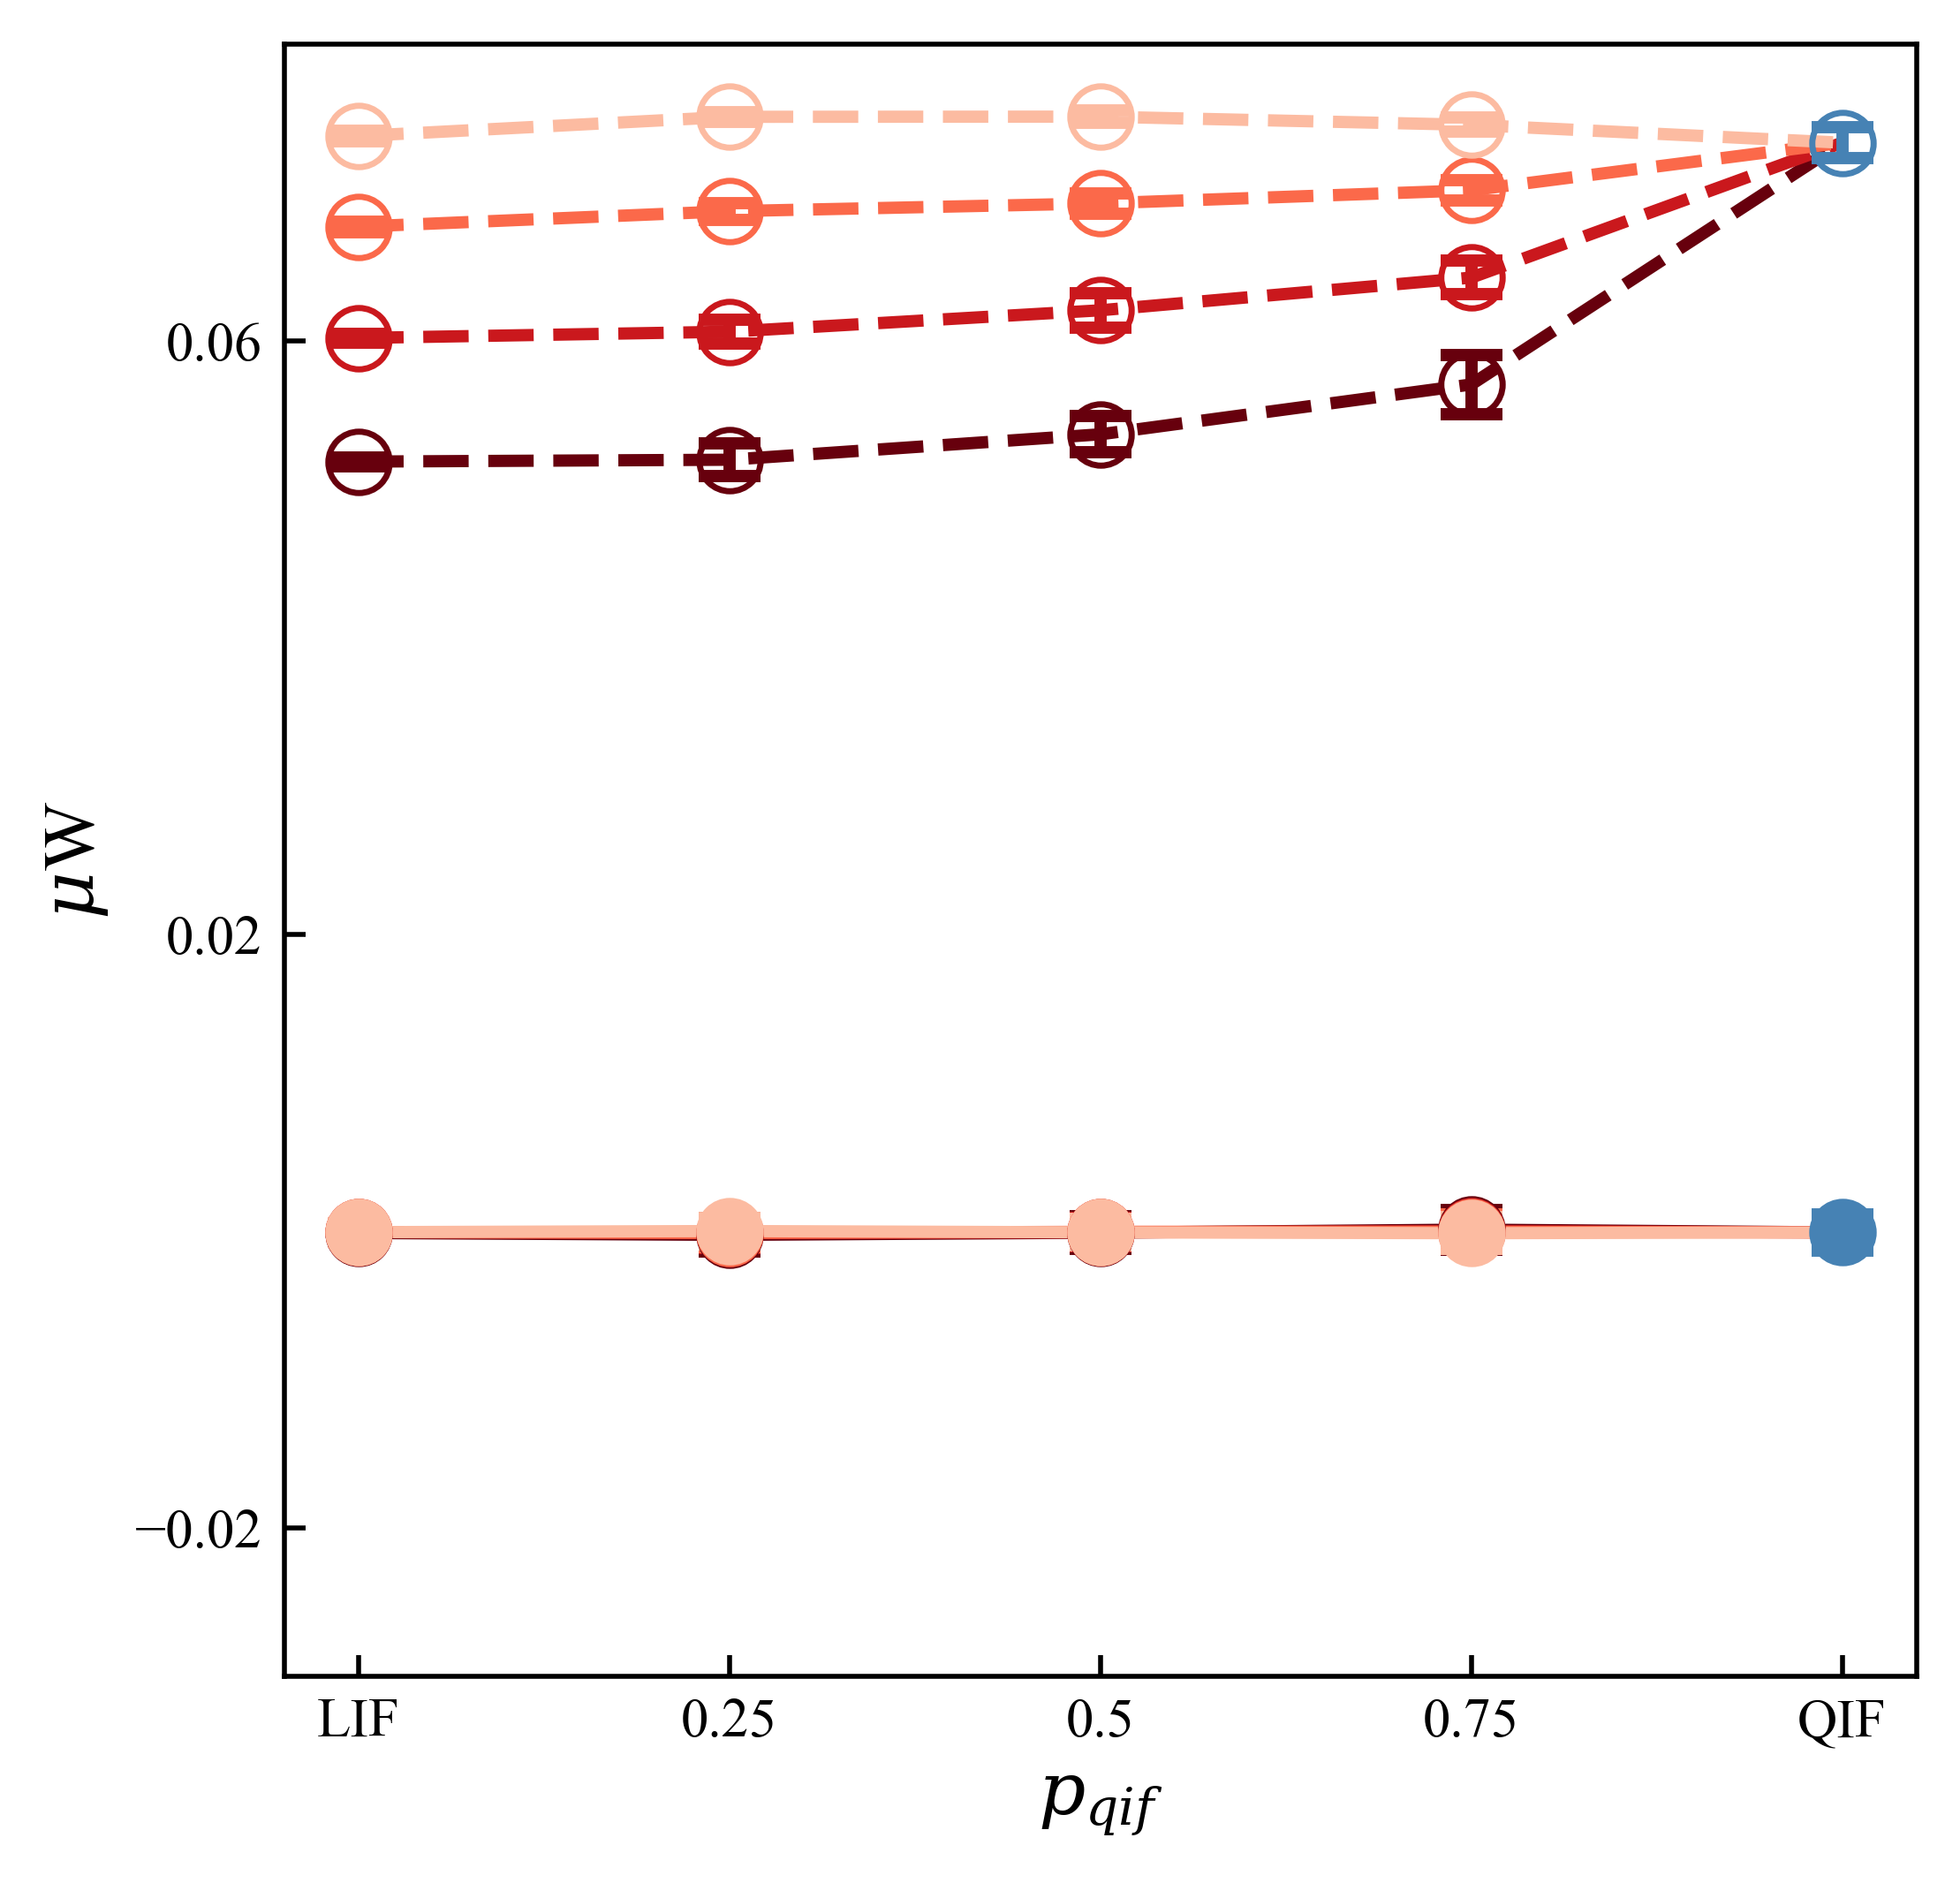

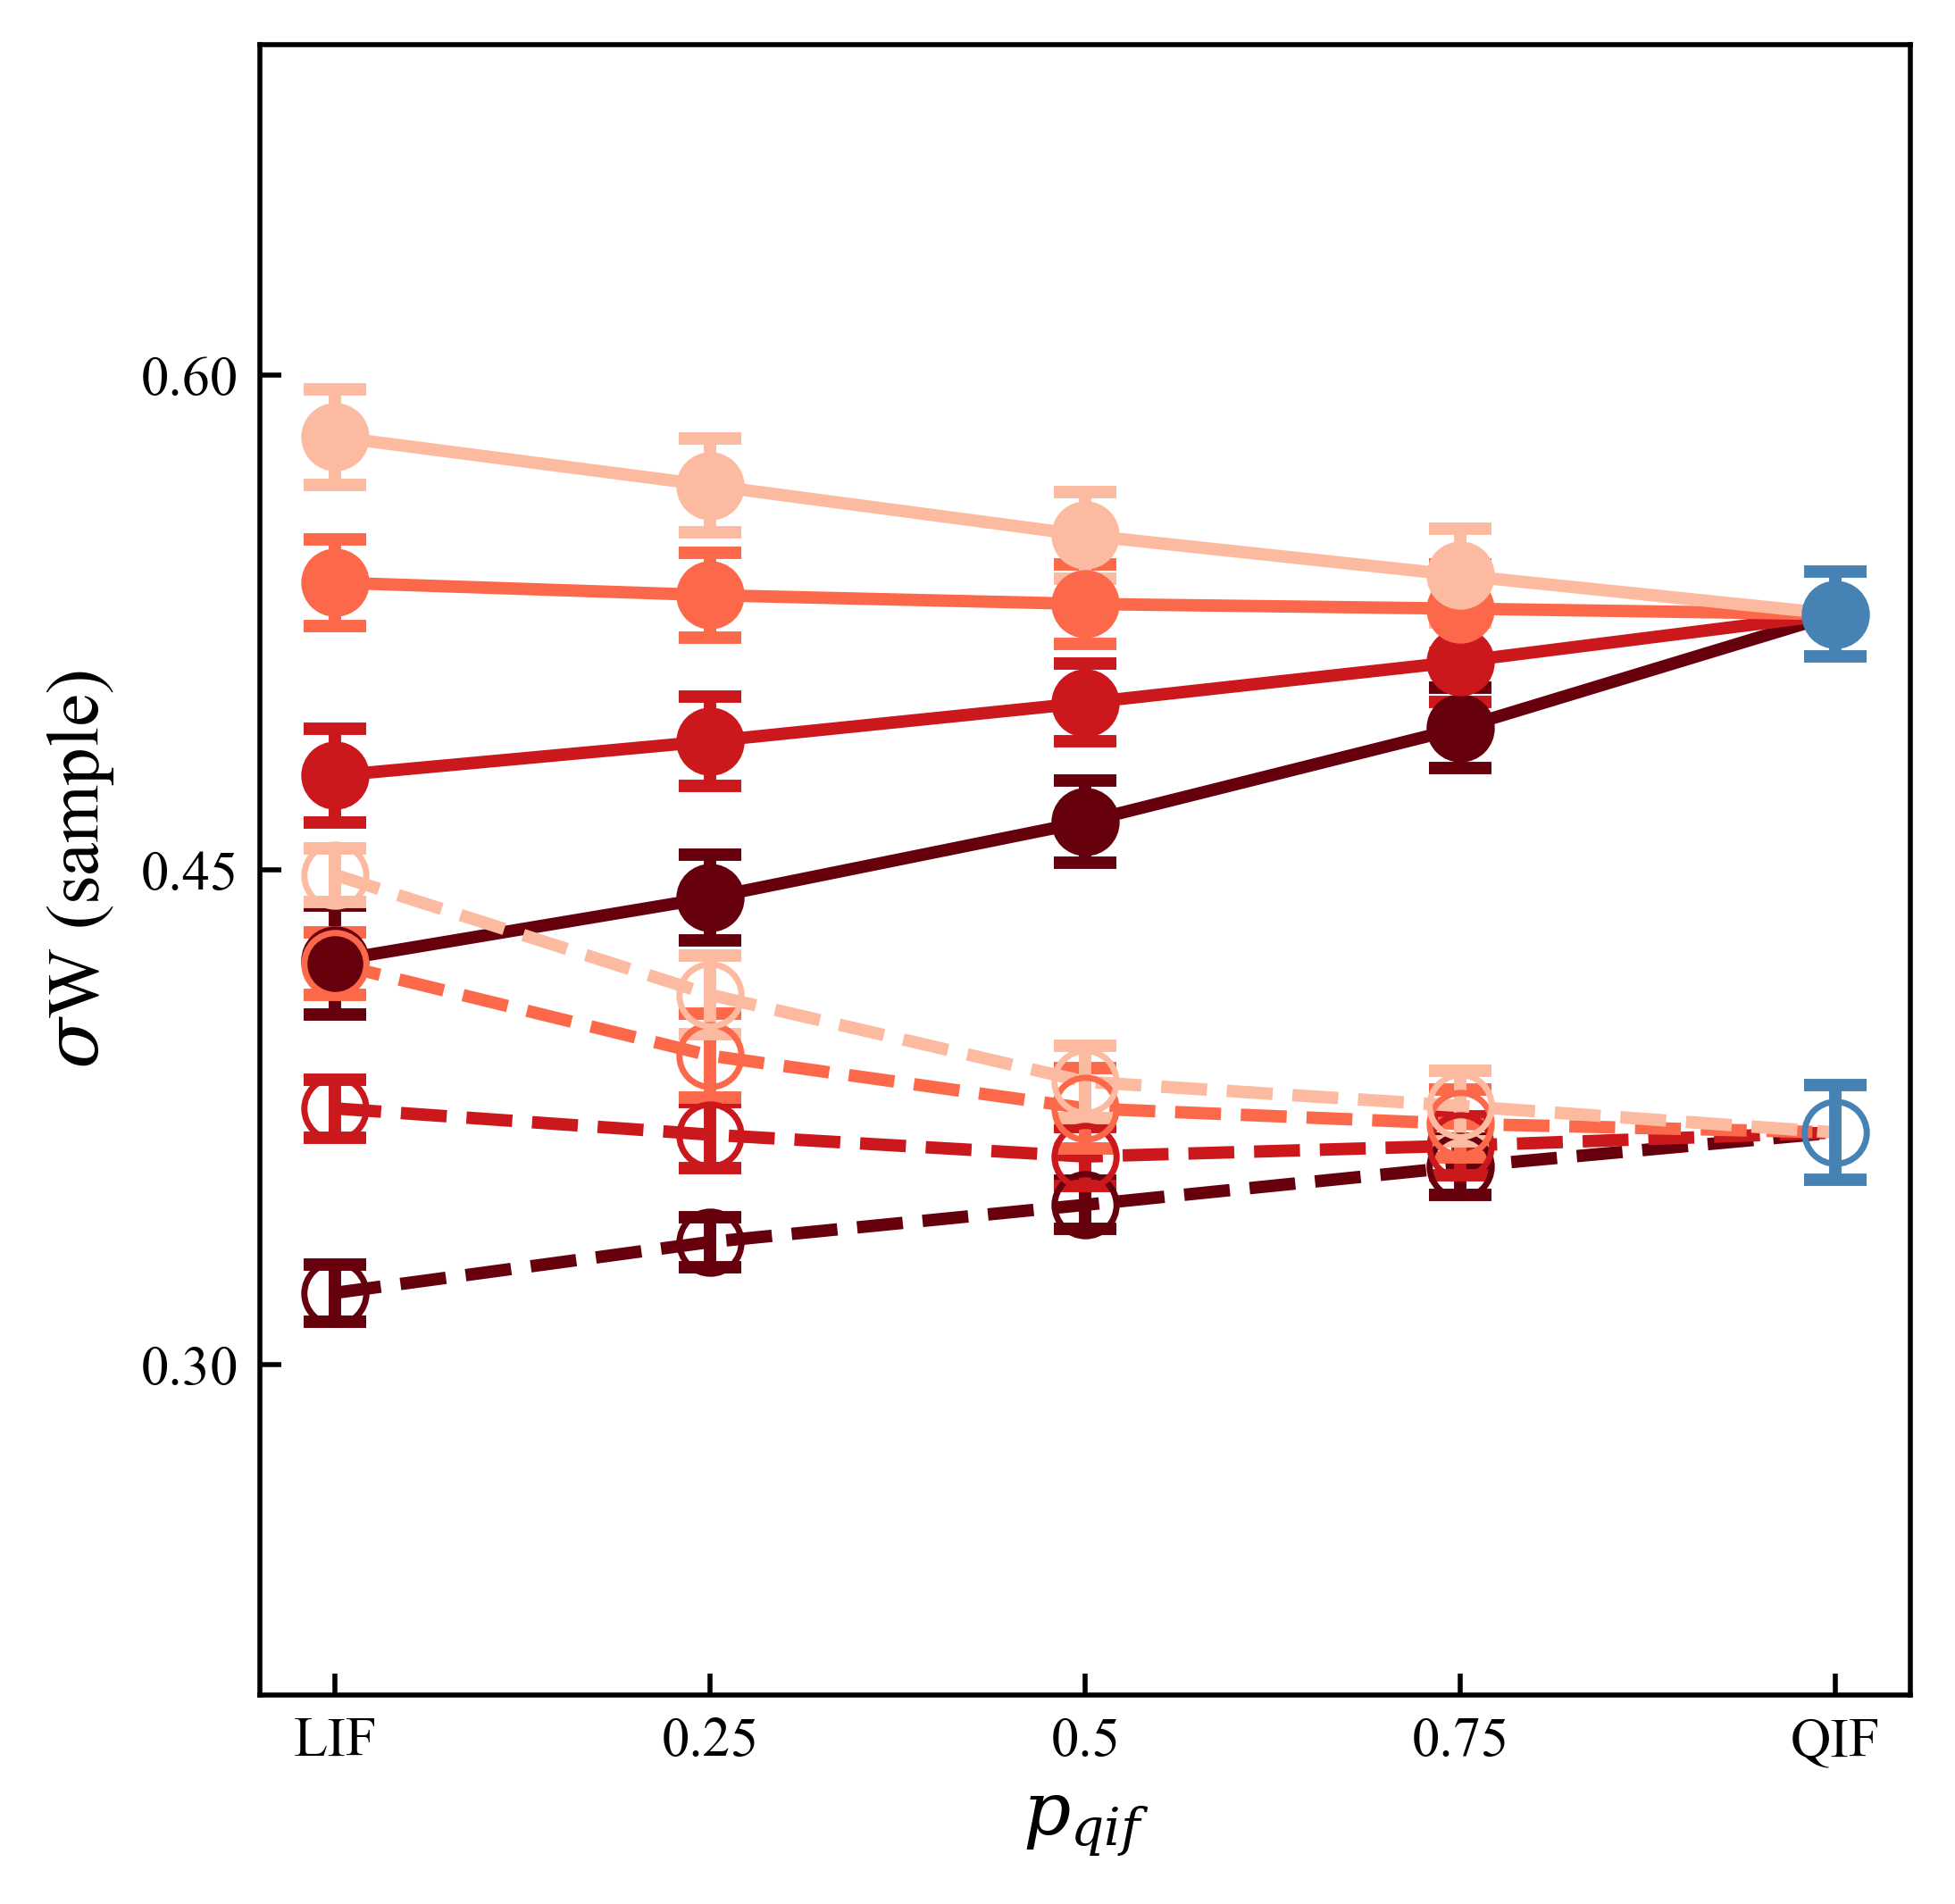

In [40]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
from brokenaxes import brokenaxes
import matplotlib.lines as mlines
from pathlib import Path
import os

# Load matplotlib style
plt.style.use('plos.mplstyle')

# Import and load color map
from color_map import make_color_map
v_rest = [-22, -17, -12.3, -8.5]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest

pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Base path
base_path = Path(r"J:\ordinary_simulations")  # ordinary simulations
base_path.mkdir(parents=True, exist_ok=True)

# Figure path
figure_folder = 'figures_all/july'
loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats

wDF = loaded_df.copy()


# ------------------------------------------------------------

# Loop variables 

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
dynamics = ['oscillations', 'sequences']
seed_number = [i for i in range(0, 50)]
columns = ['mean', 'std_sample']
x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

# ------------------------------------------------------------

# Figure loop


for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    figname = f"both_heterogenous_{c}-vs-pqif_filtered.svg"

    for dyn in dynamics:
        
        simulation_number, fillstyle, linestyle = ([i for i in range(1,5)], 'full', '-') if dyn == 'oscillations' else ([i for i in range(9,13)], 'none', '--')


        for sim, vr, f in zip(simulation_number, vrest, slope):
        

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()  # sample std by default


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]


            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', fillstyle=fillstyle, capsize=5, capthick=2, markersize=10, elinewidth=2, color=color_map_vrest[vr], label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], linewidth=2, label=None)

        
        ########## Title and tick labels ##########

        if c == 'std_sample':
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\sigma$W (sample)"
            ax.set_yticks(np.linspace(0.3, 0.6, 3))
            ax.set_ylim(0.2, 0.7)

        elif c == "mean":
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\mu$W"
            # ax.set_ylim(-0.08, 0.08)
            ax.set_yticks(np.linspace(-0.02, 0.06, 3))
            ax.set_ylim(-0.03, 0.08)


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None


        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, capthick=2, fillstyle=fillstyle, elinewidth=2, markersize=10, color='steelblue', label=label)


    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    ax.set_box_aspect(1)

    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()


dynamics/config: oscillations


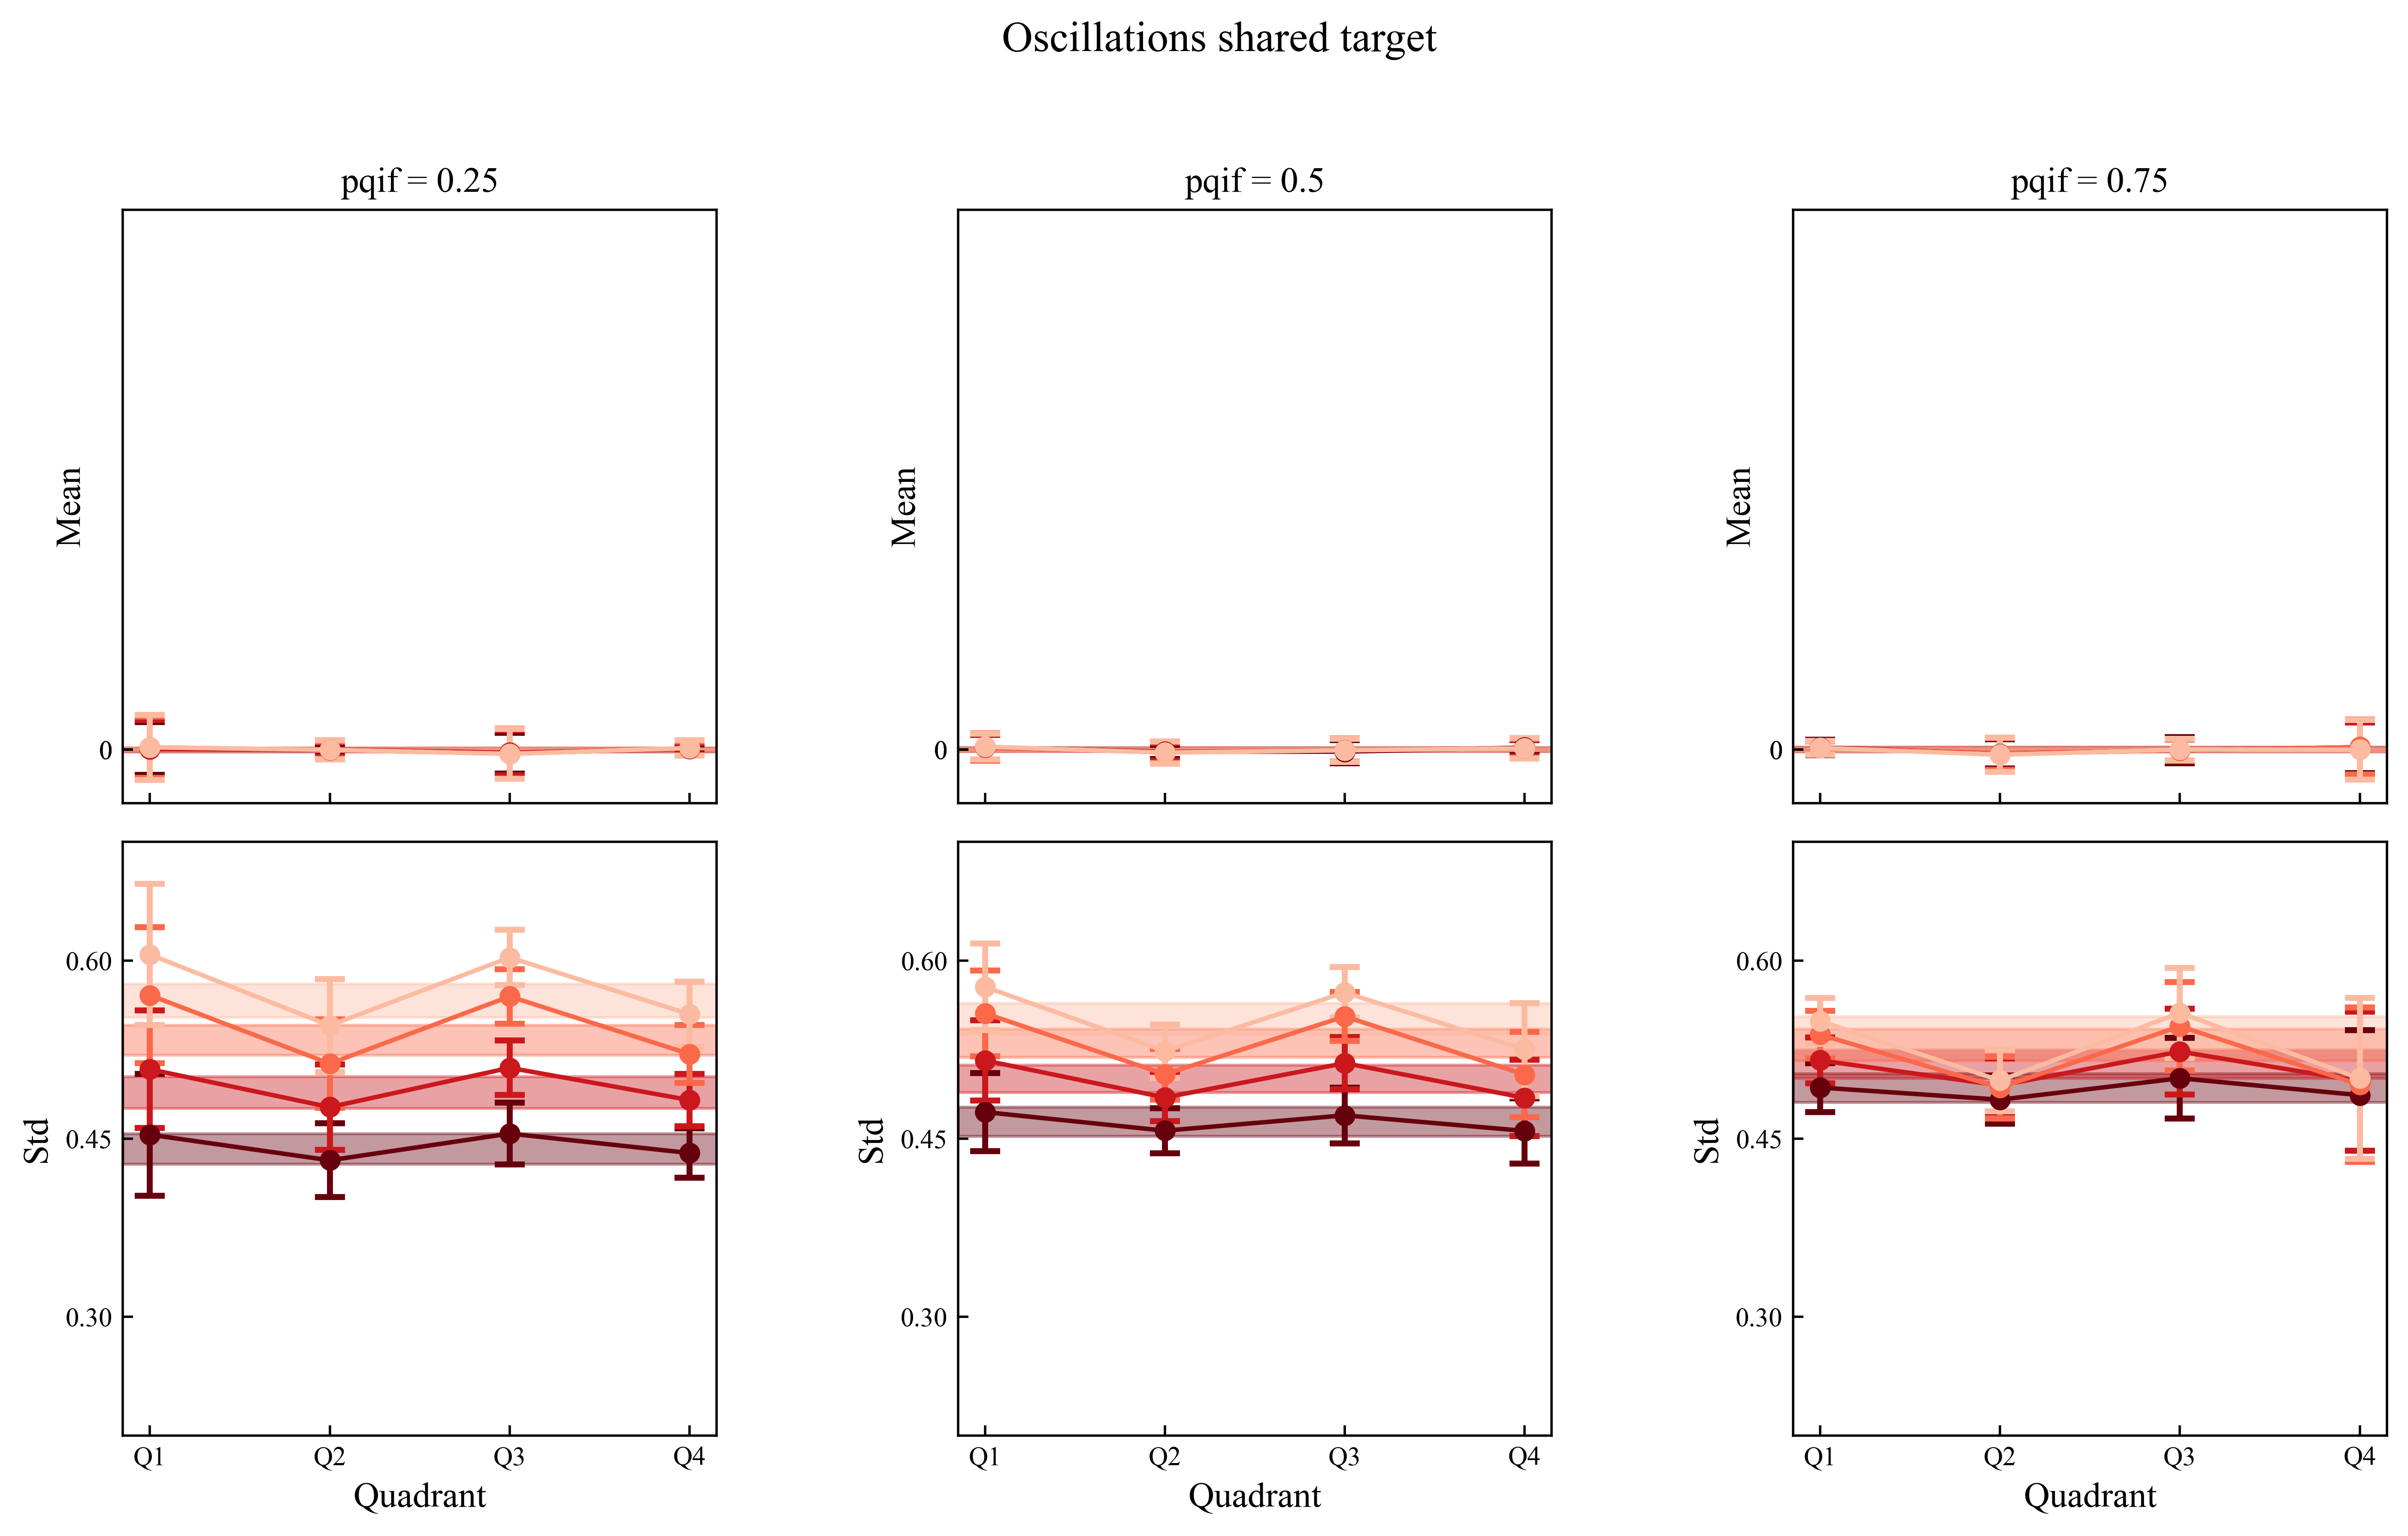

Saved: figures_all\july\oscillations_subpopulations_mean_std.svg
dynamics/config: sequences


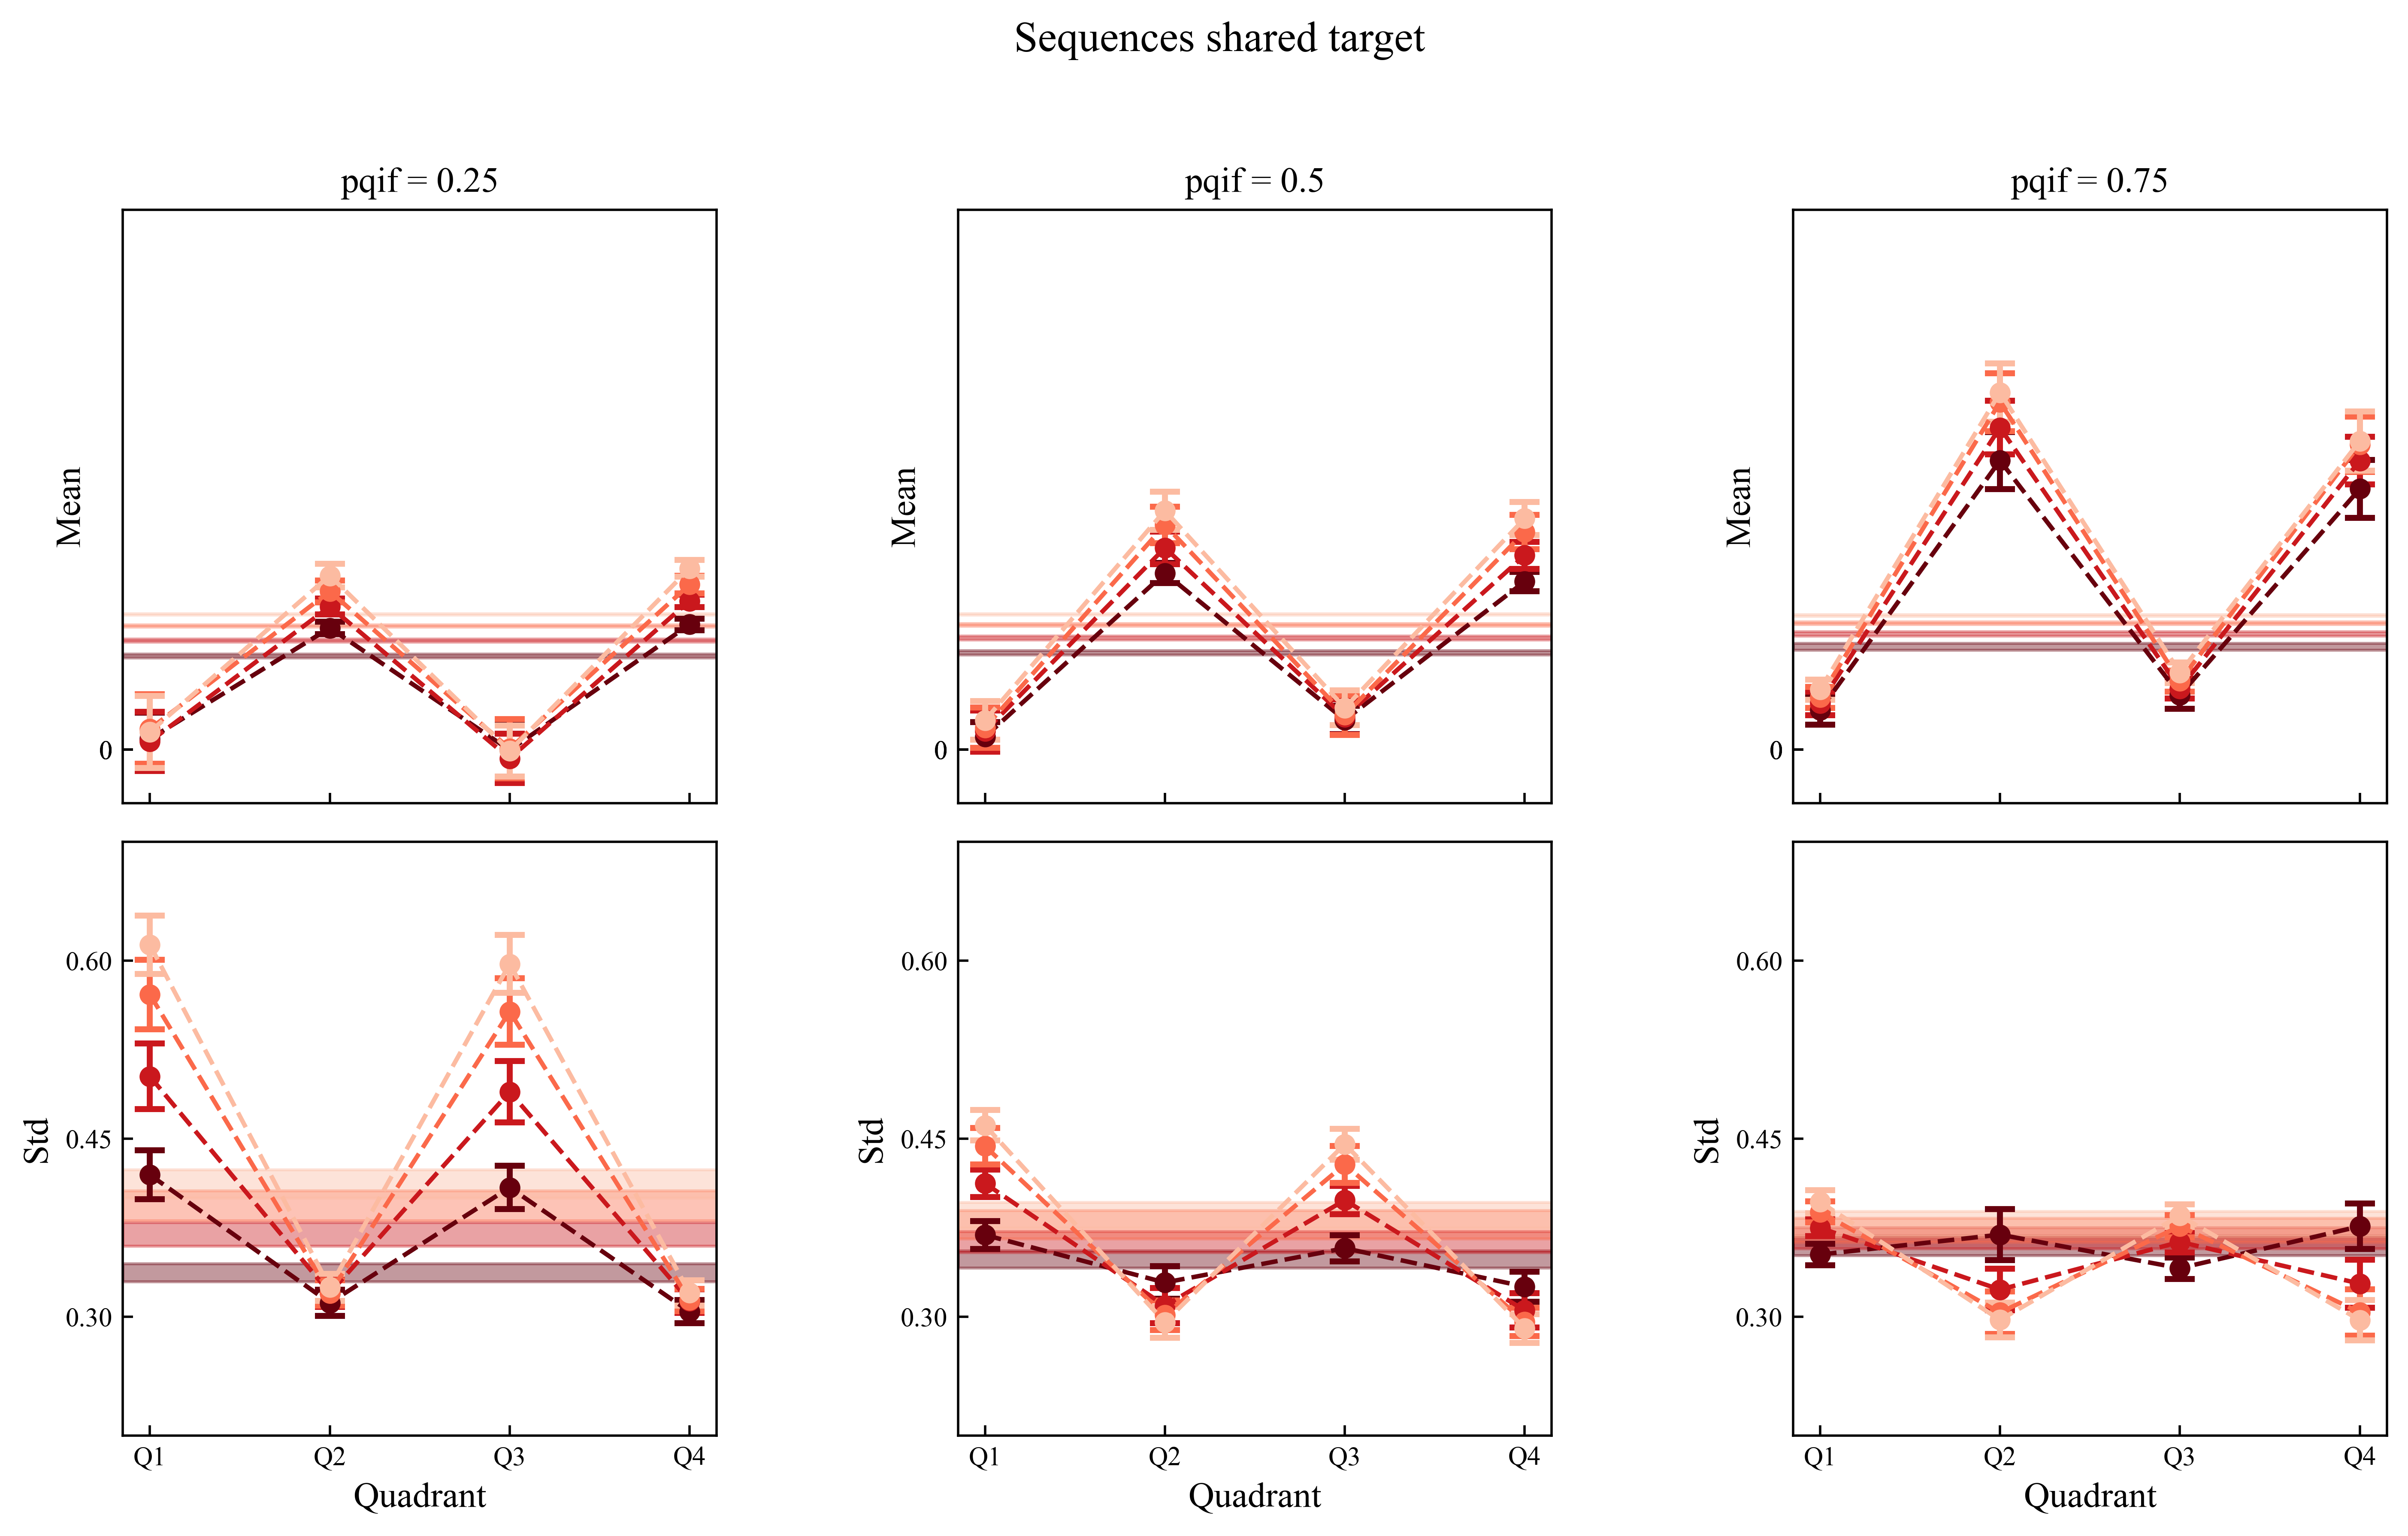

Saved: figures_all\july\sequences_subpopulations_mean_std.svg


In [41]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from color_map import make_color_map


plt.style.use("plos.mplstyle")

BASE_PATH = Path(r"J:\ordinary_simulations")
FIGURES_DIR = Path(r"figures_all\july")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PQIFS_TO_PLOT = [0.25, 0.5, 0.75]
ILOOP_INITIAL = 0
ILOOP_FINAL = 11

QUADRANT_NAMES = ["Q1", "Q2", "Q3", "Q4"]


# ------------------------------------------------------------
# Helpers

def load_matrix(path: Path) -> np.ndarray:
    return np.genfromtxt(path, delimiter=",")


def matrix_path(base_path: Path, sim: int, pqif: float, iloop: int, seed: int) -> Path:
    return (
        base_path
        / f"simulation_{sim}"
        / f"simulation_{sim}_connectivity_matrix"
        / f"simulation_{sim}_connectivity_pqif_{pqif}_iloop_{iloop}_seed_{seed}"
    )


def get_quadrants(W: np.ndarray, pqif: float) -> list[np.ndarray]:
    """
    Split matrix into four quadrants. For mixed QIF/LIF networks, pqif determines the split.
    """
    N = W.shape[0]
    h = int(round(pqif * N))

    return [
        W[:h, :h],
        W[:h, h:],
        W[h:, :h],
        W[h:, h:],
    ]


def summarize_matrix(W0: np.ndarray, W_final: np.ndarray, pqif: float) -> dict[str, np.ndarray]:
    """
    Mask initially absent connections, then compute quadrant-wise mean and std.
    """
    mask_zero = np.isclose(W0, 0.0)
    W = np.where(mask_zero, np.nan, W_final)

    quadrants = get_quadrants(W, pqif)

    means = []
    stds = []

    for Q in quadrants:
        data = Q[~np.isnan(Q)]
        means.append(np.nan if data.size == 0 else np.mean(data))
        stds.append(np.nan if data.size == 0 else np.std(data))

    return {
        "mean": np.array(means),
        "std": np.array(stds),
    }

def summarize_full_matrix(W0: np.ndarray, W_final: np.ndarray) -> dict[str, float]:
    """
    Mask initially absent connections, then compute full-matrix mean and std.
    """
    mask_zero = np.isclose(W0, 0.0)
    W = np.where(mask_zero, np.nan, W_final)

    data = W[~np.isnan(W)]

    return {
        "mean": np.nan if data.size == 0 else np.mean(data),
        "std": np.nan if data.size == 0 else np.std(data),
    }


def aggregate(values: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """
    Return mean and std across seeds.
    """
    values = np.asarray(values, dtype=float)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0)


# ------------------------------------------------------------

# Main plotting loop

for cfg in configs:
    print(f"dynamics/config: {cfg.name}")

    color_map_gain = make_color_map(cfg.gains, plt.cm.Reds)

    results = defaultdict(
    lambda: defaultdict(
        lambda: {
            "mean": [],
            "std": [],
            "global_mean": [],
            "global_std": [],
        }
    )
)

    for sim_param, pqif, seed, _ in cfg.iter_params():
        if pqif not in PQIFS_TO_PLOT:
            continue

        sim = sim_param.sim
        gain = sim_param.gain

        path_initial = matrix_path(BASE_PATH, sim, pqif, ILOOP_INITIAL, seed)
        path_final = matrix_path(BASE_PATH, sim, pqif, ILOOP_FINAL, seed)

        if not path_initial.exists() or not path_final.exists():
            print(f"Missing file for sim={sim}, pqif={pqif}, seed={seed}")
            continue

        W0 = load_matrix(path_initial)
        W_final = load_matrix(path_final)

        summary = summarize_matrix(W0, W_final, pqif)
        global_summary = summarize_full_matrix(W0, W_final)

        results[pqif][gain]["mean"].append(summary["mean"])
        results[pqif][gain]["std"].append(summary["std"])

        results[pqif][gain]["global_mean"].append(global_summary["mean"])
        results[pqif][gain]["global_std"].append(global_summary["std"])

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(12, 7),
        sharex=True,
    )

    for col, pqif in enumerate(PQIFS_TO_PLOT):
        ax_mean = axes[0, col]
        ax_std = axes[1, col]

        for gain in cfg.gains:
            if gain not in results[pqif]:
                continue

            mean_y, mean_err = aggregate(results[pqif][gain]["mean"])
            std_y, std_err = aggregate(results[pqif][gain]["std"])

            global_mean_y = np.nanmean(results[pqif][gain]["global_mean"])
            global_mean_err = np.nanstd(results[pqif][gain]["global_mean"])

            global_std_y = np.nanmean(results[pqif][gain]["global_std"])
            global_std_err = np.nanstd(results[pqif][gain]["global_std"])

            color = color_map_gain[gain]

            if cfg.name == "oscillations":
                linestyle = '-'
                fillstyle = 'full'
            else:
                linestyle = '--'
                fillstyle = None

            ax_mean.errorbar(
                QUADRANT_NAMES,
                mean_y,
                yerr=mean_err,
                marker="o",
                linestyle=linestyle,
                fillstyle=fillstyle,
                elinewidth=2,
                capsize=5,
                capthick=2,
                color=color,
                label=f"Gain = {gain}",
            )

            ax_mean.axhspan(
            global_mean_y - global_mean_err,
            global_mean_y + global_mean_err,
            color=color,
            alpha=0.4,
            zorder=0,
            )


            ax_std.errorbar(
                QUADRANT_NAMES,
                std_y,
                yerr=std_err,
                marker="o",
                linestyle=linestyle,
                fillstyle=fillstyle,
                elinewidth=2,
                capsize=5,
                capthick=2,
                color=color,
                label=f"Gain = {gain}",
            )

            ax_std.axhspan(
                global_std_y - global_std_err,
                global_std_y + global_std_err,
                color=color,
                alpha=0.4,
                zorder=0,
            )

        ax_mean.set_title(f"pqif = {pqif}")
        ax_mean.set_ylabel("Mean")
        ax_std.set_ylabel("Std")
        ax_std.set_xlabel("Quadrant")

        # ax_mean.set_ylim(-0.05, 0.30)
        # ax_std.set_ylim(0.25, 0.75)

        ax_mean.set_box_aspect(1)
        ax_std.set_box_aspect(1)
        ax_mean.set_yticks(np.round(np.linspace(0, 0.26, 3)))
        ax_mean.set_ylim(-0.03, 0.30)
        ax_std.set_yticks(np.linspace(0.3, 0.6, 3))
        ax_std.set_ylim(0.2, 0.7)
        # ax.set_yticks(np.round(np.linspace(-0.08, 0.110, 4), decimals=2))

    # handles, labels = axes[0, 0].get_legend_handles_labels()
    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     ncol=len(handles),
    #     frameon=False,
    # )

    fig.suptitle(f"{cfg.name.capitalize()} shared target", y=1.02)

    fig.tight_layout()

    fig_path = FIGURES_DIR / f"{cfg.name}_subpopulations_mean_std.svg"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    # plt.close(fig)

    print(f"Saved: {fig_path}")

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Loop variables
dynamics = ["oscillations", "sequences"]
slope_qif = 10.74
pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]


# Motifs

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}


dfs = []

figure_folder = 'figures_all/july'  # Figure path
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

# loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats
# wDF = loaded_df.copy()


for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    for sim, vr, f in zip(simulation_number, vrest, slope):

        dataframe_title = base_path / f'simulation_{sim}/simulation_{sim}_results.csv'
        df_results = pd.read_csv(dataframe_title)  # Has header


        for pqif in pqif_values:


            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]

            df_temp = df_filtered.copy()

            if pqif == 1:
                vr = None
                f = slope_qif

            df_temp['sim'] = sim
            df_temp['vrest'] = vr
            df_temp['gain'] = f
            


            dfs.append(df_temp)


vertical_stack = pd.concat(dfs, axis=0)
display(vertical_stack)  # All in one dataframe
vertical_stack.to_csv('motif_data.csv', index=False)  # Make csv


C:\Users\snrambo\AppData\Local\Temp\ipykernel_12448\4078229277.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vertical_stack = pd.concat(dfs, axis=0)


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,vrest,gain
1615,0.0,0,15,10.839460,-0.000692,-0.000280,-0.004894,-0.000063,1,-8.5,14.44
1631,0.0,1,15,10.849924,-0.009845,0.000726,-0.004898,0.000499,1,-8.5,14.44
1647,0.0,2,15,9.541773,-0.009343,0.001082,-0.004896,0.000324,1,-8.5,14.44
1663,0.0,3,15,10.539035,0.010592,-0.000913,-0.004929,-0.000067,1,-8.5,14.44
1679,0.0,4,15,11.645812,-0.018420,-0.000104,-0.004902,-0.000066,1,-8.5,14.44
...,...,...,...,...,...,...,...,...,...,...,...
2335,1.0,45,15,8.751116,0.097426,0.022160,-0.004764,-0.003509,12,NaN,10.74
2351,1.0,46,15,7.389655,0.118143,0.014034,-0.004703,-0.002432,12,NaN,10.74
2367,1.0,47,15,8.641378,0.109758,0.020742,-0.004740,-0.003174,12,NaN,10.74
2383,1.0,48,15,8.577522,0.113766,0.019109,-0.004728,-0.002889,12,NaN,10.74


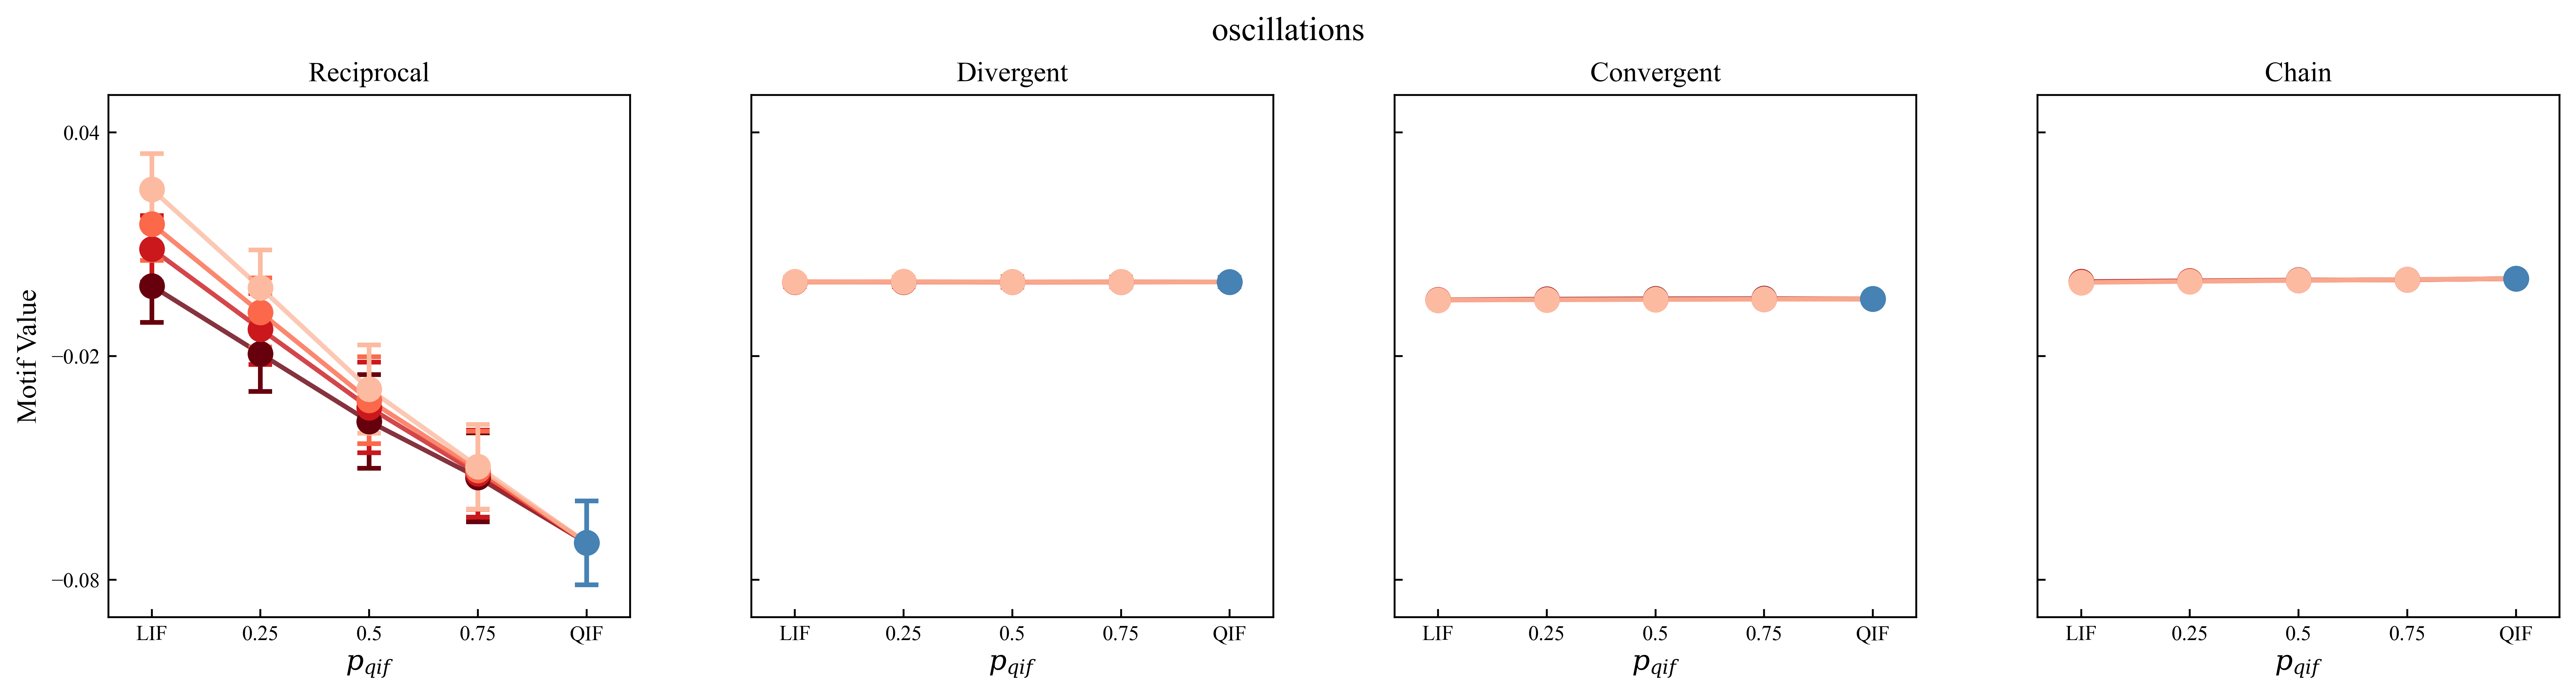

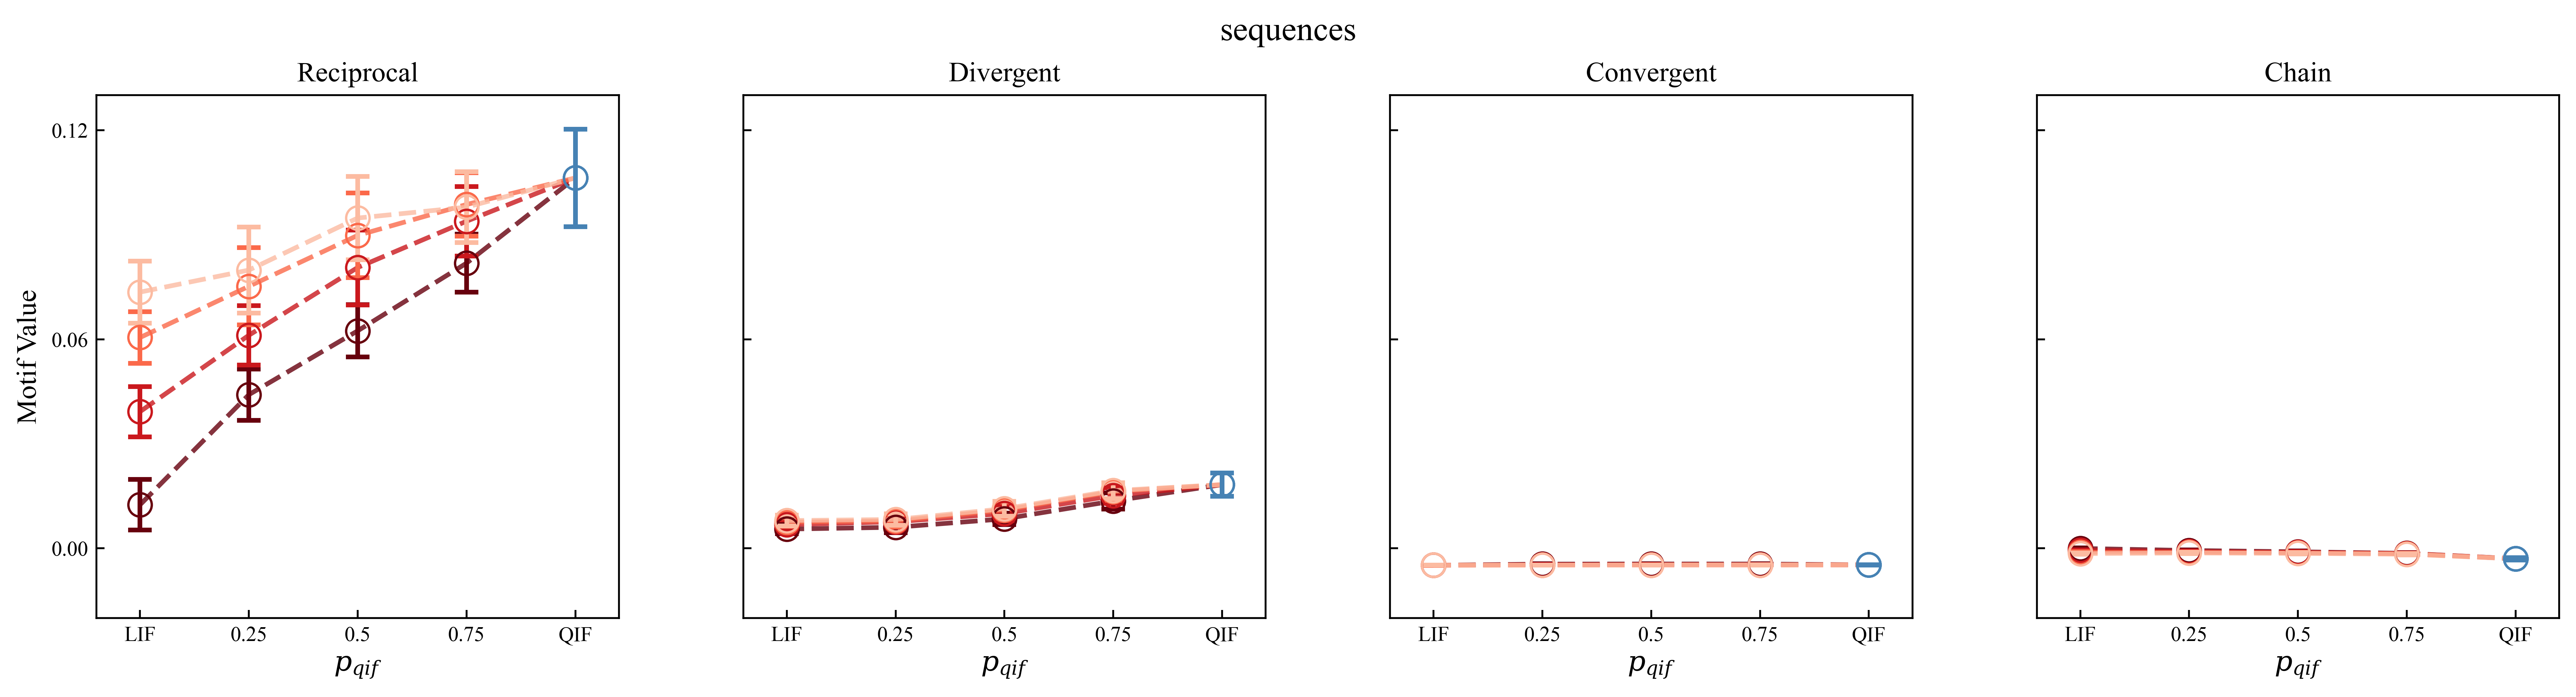

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------

# Loop variables

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
dynamics = ["oscillations", "sequences"]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']


# ------------------------------------------------------------

# Labels

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

# ------------------------------------------------------------

# Path handling

df_motif = pd.read_csv("motif_data.csv")  # The csv made with all motif data
figure_folder = 'figures_all/july'  # Figure path
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------

# Plotting loop

for dyn in dynamics:
    figname = f"{dyn}_motifs"


    simulation_number, linestyle = (  # Linestyle for each dynamics
        (range(1, 5), "-") if dyn == "oscillations"
        else (range(9, 13), "--")
    )

    fillstyle = "full" if dyn == "oscillations" else "none" # Marker fill style for each dynamics


    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for sim, vr, f in zip(simulation_number, vrest, slope):

        xs = pqif_values
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        for pqif in pqif_values:

            # Get all data

            sim_for_qif = simulation_number[0] if pqif == 1 else sim

            df_filtered = df_motif[
                (df_motif["pqif"] == pqif)
                & (df_motif["sim"] == sim_for_qif)
                & (df_motif["nloop"] == 15)
            ]

            stats = df_filtered[motifs].agg(["mean", "std"])

            for motif in motifs:
                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        # Color
        point_colors = [
            color_map_vrest[vr] if pqif < 1 else "steelblue"
            for pqif in pqif_values
        ]

        for i, motif in enumerate(motifs):
            # Plot errorbar points and line through
            ax = axs[i]

            # line through all points
            ax.plot(
                xs,
                ys[motif],
                linestyle=linestyle,
                color=color_map_vrest[vr],
                alpha=0.8,
                linewidth=2,
                label=f,
            )

            # colored errorbars on top
            for x, y, yerr, c in zip(xs, ys[motif], yerrs[motif], point_colors):
                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    marker="o",
                    fillstyle=fillstyle,
                    linestyle="none",
                    color=c,
                    ecolor=c,
                    markersize=10,
                    elinewidth=2,
                    capsize=5,
                    capthick=2,
                    alpha=1,
                )

            # ax.axhline(0, linewidth=0.2, color="black")
            if dyn == 'oscillations':
                ax.set_yticks(np.linspace(-0.08, 0.04, 3))
                ax.set_ylim(-0.09, 0.05)
            else:
                ax.set_yticks(np.linspace(0, 0.12, 3))
                ax.set_ylim(-0.02, 0.13)
            ax.set_xticks(pqif_values, names)
            ax.set_xlim(-0.1, 1.1)
            ax.set_title(motif_labels[motif])
            ax.set_box_aspect(1)
            ax.set_xlabel(r"$p_{qif}$")

    axs[0].set_ylabel("Motif Value")
    fig.suptitle(dyn)
    fig.tight_layout()
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()